In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install vaderSentiment


Defaulting to user installation because normal site-packages is not writeable


In [8]:
df = pd.read_csv("~/Downloads/amazon.csv")  
print(df.shape)
df.head()

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [10]:
print(df['discounted_price'].head())
print(df['actual_price'].head())
print(df['discount_percentage'].head())
print(df['rating'].unique())
print(df['rating_count'].head())

0    ₹399
1    ₹199
2    ₹199
3    ₹329
4    ₹154
Name: discounted_price, dtype: object
0    ₹1,099
1      ₹349
2    ₹1,899
3      ₹699
4      ₹399
Name: actual_price, dtype: object
0    64%
1    43%
2    90%
3    53%
4    61%
Name: discount_percentage, dtype: object
['4.2' '4.0' '3.9' '4.1' '4.3' '4.4' '4.5' '3.7' '3.3' '3.6' '3.4' '3.8'
 '3.5' '4.6' '3.2' '5.0' '4.7' '3.0' '2.8' '4' '3.1' '4.8' '2.3' '|' '2'
 '3' '2.6' '2.9']
0    24,269
1    43,994
2     7,928
3    94,363
4    16,905
Name: rating_count, dtype: object


In [11]:
print(df['review_content'].iloc[0])
print(df['user_name'].iloc[0])

Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now satisfied with the quality.,This is a good product . The charging speed is slower than the original iPhone cable,Good quality, would recommend,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/81---F1ZgHL._SY88.jpg,Product had worked well till date and was having no issue.Cable is also sturdy enough...Have asked for replacement and company is doing the same...,Value for money
Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S.ARUMUGAM


In [12]:
# find the bad rating row
print(df[df['rating'] == '|'])

# check alignment between review_content and user_name splits
sample = df.iloc[0]
reviews_split = sample['review_content'].split(',')
users_split = sample['user_name'].split(',')
print(len(reviews_split), len(users_split))
print(reviews_split)
print(users_split)

      product_id                                       product_name  \
1279  B08L12N5H1  Eureka Forbes car Vac 100 Watts Powerful Sucti...   

                                               category discounted_price  \
1279  Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...           ₹2,099   

     actual_price discount_percentage rating rating_count  \
1279       ₹2,499                 16%      |          992   

                                          about_product  \
1279  No Installation is provided for this product|1...   

                                                user_id  \
1279  AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...   

                                              user_name  \
1279  Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...   

                                              review_id  \
1279  R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...   

                                           review_title  \
1279  Decent product,doesn't pick up sand,Ok o

In [14]:
df = df.drop(index=1279).reset_index(drop=True)

In [15]:
# Strip ₹ and , from price columns, convert to float
df['discounted_price'] = df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Strip % from discount_percentage, convert to float
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)

# Rating is clean now that row 1279 is dropped — just convert
df['rating'] = df['rating'].astype(float)

# Strip , from rating_count, convert to float (keeps NaN for the 2 nulls)
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False).astype(float)

# Check it worked
df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   discounted_price     1463 non-null   float64
 1   actual_price         1463 non-null   float64
 2   discount_percentage  1463 non-null   float64
 3   rating               1463 non-null   float64
 4   rating_count         1461 non-null   float64
dtypes: float64(5)
memory usage: 57.3 KB


In [16]:
df = df.dropna(subset=['rating_count']).reset_index(drop=True)
print(df.shape)  # should now be (1461, 16)

(1461, 16)


In [17]:
print(df['category'].nunique())
print(df['category'].unique()[:10])

211
['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables'
 'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables'
 'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions'
 'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls'
 'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions'
 'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables'
 'Electronics|HomeAudio|Accessories|SpeakerAccessories|Mounts'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables']


In [18]:
df['main_category'] = df['category'].str.split('|').str[0]
print(df['main_category'].value_counts())

main_category
Electronics              526
Computers&Accessories    451
Home&Kitchen             446
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


In [19]:
category_rating = df.groupby('main_category')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(category_rating)

                           mean  count
main_category                         
OfficeProducts         4.309677     31
Toys&Games             4.300000      1
HomeImprovement        4.250000      2
Computers&Accessories  4.155654    451
Electronics            4.081749    526
Home&Kitchen           4.040583    446
Health&PersonalCare    4.000000      1
MusicalInstruments     3.900000      2
Car&Motorbike          3.800000      1


In [20]:
main_cats = ['Electronics', 'Computers&Accessories', 'Home&Kitchen']
df_main = df[df['main_category'].isin(main_cats)].copy()
print(df_main.shape)

(1423, 17)


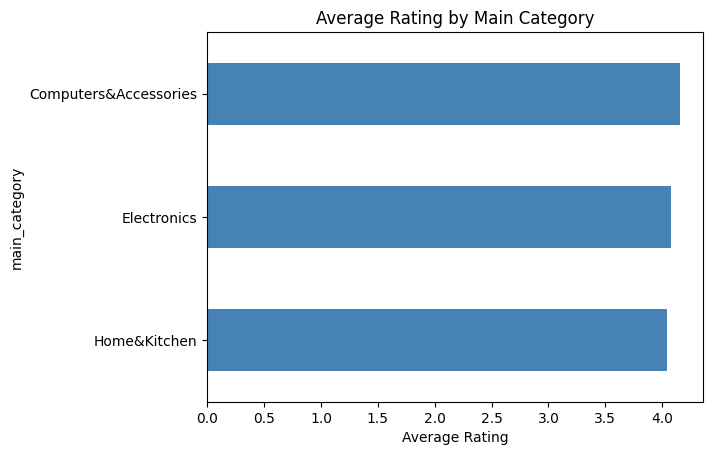

In [22]:
category_avg = df_main.groupby('main_category')['rating'].mean().sort_values()
category_avg.plot(kind='barh', color='steelblue')
plt.xlabel('Average Rating')
plt.title('Average Rating by Main Category')
plt.show()

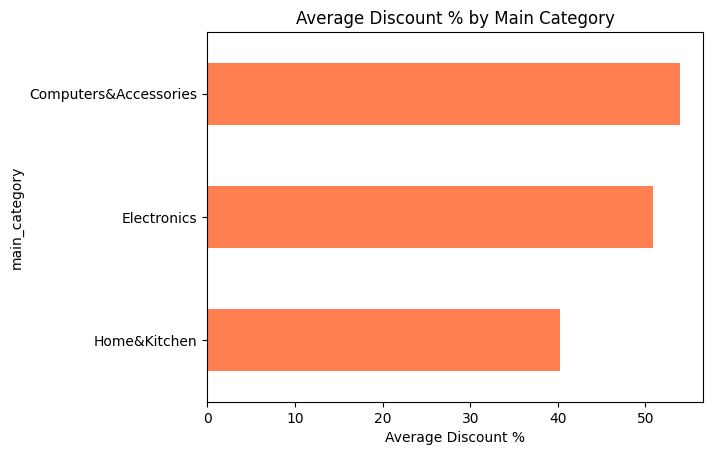

In [23]:
category_avg = df_main.groupby('main_category')['discount_percentage'].mean().sort_values()
category_avg.plot(kind='barh', color='coral')
plt.xlabel('Average Discount %')
plt.title('Average Discount % by Main Category')
plt.show()

In [28]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# test it on one review first, before writing the full function
test_score = analyzer.polarity_scores(df_main['review_content'].iloc[0])
print(test_score)
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'


{'neg': 0.031, 'neu': 0.754, 'pos': 0.215, 'compound': 0.8974}


In [29]:
df_main['sentiment'] = df_main['review_content'].apply(get_sentiment)

print(df_main['sentiment'].value_counts())

sentiment
positive    1359
negative      60
neutral        4
Name: count, dtype: int64


In [30]:
sentiment_by_category = df_main.groupby(['main_category', 'sentiment']).size().unstack(fill_value=0)
print(sentiment_by_category)

sentiment              negative  neutral  positive
main_category                                     
Computers&Accessories        15        2       434
Electronics                  19        1       506
Home&Kitchen                 26        1       419


In [31]:
negative_reviews = df_main[df_main['sentiment'] == 'negative']
print(negative_reviews[['product_name', 'main_category', 'review_content']].head(10))

                                          product_name          main_category  \
22   Samsung 80 cm (32 Inches) Wondertainment Serie...            Electronics   
38   OnePlus 126 cm (50 inches) Y Series 4K Ultra H...            Electronics   
45   Wecool Nylon Braided Multifunction Fast Chargi...  Computers&Accessories   
85   OnePlus 108 cm (43 inches) Y Series 4K Ultra H...            Electronics   
115  Portronics Konnect L POR-1403 Fast Charging 3A...  Computers&Accessories   
126  AmazonBasics 3 Feet High Speed HDMI Male to Fe...            Electronics   
134  AmazonBasics New Release ABS USB-A to Lightnin...  Computers&Accessories   
138  LRIPL Compatible Sony Bravia LCD/led Remote Wo...            Electronics   
145  Airtel DigitalTV DTH Remote SD/HD/HD Recording...            Electronics   
152  Samsung 80 cm (32 inches) Wondertainment Serie...            Electronics   

                                        review_content  
22   Overall good.,TV picture ok smart betterSound 

In [32]:
print("Overall sentiment:", df_main['sentiment'].value_counts().to_dict())
print("\nSentiment by category:\n", sentiment_by_category)
print("\nAvg rating by category:\n", df_main.groupby('main_category')['rating'].mean())
print("\nAvg discount % by category:\n", df_main.groupby('main_category')['discount_percentage'].mean())

Overall sentiment: {'positive': 1359, 'negative': 60, 'neutral': 4}

Sentiment by category:
 sentiment              negative  neutral  positive
main_category                                     
Computers&Accessories        15        2       434
Electronics                  19        1       506
Home&Kitchen                 26        1       419

Avg rating by category:
 main_category
Computers&Accessories    4.155654
Electronics              4.081749
Home&Kitchen             4.040583
Name: rating, dtype: float64

Avg discount % by category:
 main_category
Computers&Accessories    53.920177
Electronics              50.828897
Home&Kitchen             40.233184
Name: discount_percentage, dtype: float64


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Drop neutral (only 4 rows) — keep it a binary problem
ml_df = df_main[df_main['sentiment'] != 'neutral'].copy()

X = ml_df['review_content']
y = ml_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9577464788732394
              precision    recall  f1-score   support

    negative       0.50      0.42      0.45        12
    positive       0.97      0.98      0.98       272

    accuracy                           0.96       284
   macro avg       0.74      0.70      0.72       284
weighted avg       0.95      0.96      0.96       284

